# Notebook 06 — Feature Engineering & Normalization

**DS108 — Tiền Xử Lý Dữ Liệu**  
**Nhóm:** La Gia Hân (24520448) · Huỳnh Gia Hào (24520457)  

---

## Mục tiêu

Biến đổi `unified_v1_merged.csv` thành `final_v1_dataset.csv` sẵn sàng cho mô hình dự báo phụ tải ngắn hạn.

**Thứ tự bắt buộc: Feature Engineering TRƯỚC Scaling**  
Nếu scale trước rồi mới `shift()`, giá trị lag về mặt số học vẫn đúng, nhưng params scaler sẽ bị tính trên tập thiếu 336 dòng đầu. Quan trọng hơn, khi deploy với data mới, ta cần áp lag TRƯỚC khi scale, nên pipeline phải nhất quán.

## Pipeline notebook này

```
unified_v1_merged.csv
    → [1] Feature Engineering (time, boolean, lag + rolling)
    → [2] Drop 336 dòng đầu (do lag t-336)
    → [3] Scaling (Min-Max cho Load, Z-score cho Price)
    → [4] Validate & Lưu
    → final_v1_dataset.csv + scaler_params.json
```

## Output
- `data/processed/final_v1_dataset.csv`
- `data/processed/scaler_params.json`
- Biểu đồ → `reports/nb06/`

## 0. Setup — Working Directory & Import

In [1]:
import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# Tự động tìm repo root (notebook nằm trong notebooks/)
def find_repo_root(marker: str = 'requirements.txt') -> Path:
    """Leo ngược từ CWD cho đến khi tìm thấy file marker của repo.

    Fallback: nếu không tìm thấy marker (ví dụ môi trường chưa có
    requirements.txt), thử leo lên 1 cấp từ CWD rồi dùng thư mục đó.
    Không raise exception để notebook không crash khi clone lần đầu.
    """
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    # Fallback: nếu đang ở trong notebooks/, leo lên 1 cấp
    if current.name == 'notebooks':
        return current.parent
    # Fallback cuối: dùng CWD
    return current

ROOT = find_repo_root()
os.chdir(ROOT)
print(f"[OK] Working directory: {ROOT}")

# Paths
PROCESSED_DIR = ROOT / 'data' / 'processed'
REPORTS_DIR   = ROOT / 'reports' / 'nb06'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE         = PROCESSED_DIR / 'unified_v1_merged.csv'
OUTPUT_DATASET     = PROCESSED_DIR / 'final_v1_dataset.csv'
OUTPUT_SCALER_JSON = PROCESSED_DIR / 'scaler_params.json'

# Style biểu đồ
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = {
    'North':    '#1f77b4',
    'Central':  '#ff7f0e',
    'South':    '#2ca02c',
    'National': '#9467bd',
}

print("[OK] Import hoàn tất.")

[OK] Working directory: c:\Users\ASUS\DS108-Project
[OK] Import hoàn tất.


## 1. Đọc dữ liệu đầu vào

In [2]:
df = pd.read_csv(
    INPUT_FILE,
    encoding='utf-8-sig',
    parse_dates=['Timestamp']
)
df = df.sort_values('Timestamp').reset_index(drop=True)
INPUT_SHAPE = df.shape   # lưu lại để dùng ở section tổng kết

print(f"Shape     : {df.shape}")
print(f"Thời gian : {df['Timestamp'].min()} → {df['Timestamp'].max()}")
print(f"Tần suất  : {df['Timestamp'].diff().mode()[0]}")
print()

# Kiểm tra nhanh NaN trước khi xử lý
nan_summary = df.isnull().sum()
nan_cols = nan_summary[nan_summary > 0]
if nan_cols.empty:
    print("[OK] Không có NaN trong input — unified đã clean.")
else:
    print(f"[WARNING]  Còn {len(nan_cols)} cột có NaN:")
    print(nan_cols.to_string())

df.head(3)

Shape     : (52608, 42)
Thời gian : 2023-03-11 00:30:00 → 2026-03-11 00:00:00
Tần suất  : 0 days 00:30:00

[WARNING]  Còn 33 cột có NaN:
temp_North                2
feelslike_North           2
humidity_North            2
precip_North              2
precipprob_North          2
windspeed_North           2
cloudcover_North          2
solarradiation_North      2
uvindex_North             2
conditions_North          2
icon_North                2
temp_Central              2
feelslike_Central         2
humidity_Central          2
precip_Central            2
precipprob_Central        2
windspeed_Central         2
cloudcover_Central        2
solarradiation_Central    2
uvindex_Central           2
conditions_Central        2
icon_Central              2
temp_South                2
feelslike_South           2
humidity_South            2
precip_South              2
precipprob_South          2
windspeed_South           2
cloudcover_South          2
solarradiation_South      2
uvindex_South          

,Timestamp,Load_North,Load_Central,Load_South,Load_National,Price_North,Price_Central,Price_South,Price_National,temp_North,...,feelslike_South,humidity_South,precip_South,precipprob_South,windspeed_South,cloudcover_South,solarradiation_South,uvindex_South,conditions_South,icon_South
0,2023-03-11 00:30:00,11629.8,2095.1,12162.5,25887.4,1242.014,1230.414,1250.700,1250.700,21.4,...,24.5,85.810,0.0,0.0,12.7,26.2,0.0,0.0,Partially cloudy,partly-cloudy-night
1,2023-03-11 01:00:00,11572.7,2169.3,12164.7,25906.7,1413.199,1400.000,1420.051,1420.051,20.8,...,24.0,88.170,0.0,0.0,12.4,25.4,0.0,0.0,Partially cloudy,partly-cloudy-night
2,2023-03-11 01:30:00,11646.7,2151.6,12156.6,25954.9,1646.741,1637.750,1670.100,1670.100,20.9,...,24.0,88.385,0.0,0.0,12.7,26.2,0.0,0.0,Partially cloudy,partly-cloudy-night


## 2. Feature Engineering

### 2.1 — Time Features

In [3]:
def add_time_features(df: pd.DataFrame, ts_col: str = 'Timestamp') -> pd.DataFrame:
    """
    Thêm các đặc trưng thời gian từ cột Timestamp.

    Features:
        hour       : giờ trong ngày (0–23)
        dayofweek  : thứ trong tuần (0=Thứ 2, 6=Chủ nhật)
        month      : tháng (1–12)

    Ghi chú về tần suất 30 phút:
        Mỗi giá trị hour xuất hiện 2 lần/ngày (VD: hour=9 cho 9:00 và 9:30).
        Nếu cần phân biệt :00 và :30 → thêm `minute = dt.minute`.
        Lag features sẽ bắt được sự khác biệt này tốt hơn time feature đơn thuần.
    """
    df = df.copy()
    df['hour']      = df[ts_col].dt.hour
    df['dayofweek'] = df[ts_col].dt.dayofweek   # 0=Mon, 6=Sun
    df['month']     = df[ts_col].dt.month
    print("[OK] Time features: hour, dayofweek, month")
    return df

df = add_time_features(df)
df[['Timestamp', 'hour', 'dayofweek', 'month']].head(5)

[OK] Time features: hour, dayofweek, month


,Timestamp,hour,dayofweek,month
0,2023-03-11 00:30:00,0,5,3
1,2023-03-11 01:00:00,1,5,3
2,2023-03-11 01:30:00,1,5,3
3,2023-03-11 02:00:00,2,5,3
4,2023-03-11 02:30:00,2,5,3


### 2.2 — Boolean Features

**`is_peak`** theo Quyết định 648/QĐ-BCT (Bộ Công Thương) về khung giờ cao điểm:
- Buổi sáng: 9:00–11:30
- Buổi chiều tối: 17:00–20:00

**`is_weekend`**: Thứ 7 và Chủ nhật — phụ tải công nghiệp giảm, dân sinh tăng nhẹ

**`is_holiday`**: Ngày lễ theo Bộ luật Lao động VN

In [4]:
# ── Danh sách ngày lễ Việt Nam 2023–2026 ─────────────────────────────────────
# Nguồn: Bộ luật Lao động + thông báo nghỉ lễ hàng năm
_VN_HOLIDAY_STRINGS = [
    # 2023
    '2023-01-01',                                            # Tết Dương lịch
    '2023-01-20','2023-01-21','2023-01-22','2023-01-23',     # Tết Nguyên Đán
    '2023-01-24','2023-01-25','2023-01-26',
    '2023-04-22',                                            # Giỗ Tổ Hùng Vương
    '2023-04-29','2023-04-30',                               # 30/4
    '2023-05-01',                                            # 1/5
    '2023-09-02','2023-09-04',                               # 2/9
    # 2024
    '2024-01-01',
    '2024-02-08','2024-02-09','2024-02-10','2024-02-11',     # Tết Giáp Thìn
    '2024-02-12','2024-02-13','2024-02-14',
    '2024-04-18',                                            # Giỗ Tổ
    '2024-04-26','2024-04-30',
    '2024-05-01',
    '2024-09-02','2024-09-03',
    # 2025
    '2025-01-01',
    '2025-01-25','2025-01-26','2025-01-27','2025-01-28',     # Tết Ất Tỵ
    '2025-01-29','2025-01-30','2025-01-31',
    '2025-04-07',                                            # Giỗ Tổ
    '2025-04-30',
    '2025-05-01',
    '2025-09-01','2025-09-02',
    # 2026
    '2026-01-01',
    '2026-02-16','2026-02-17','2026-02-18','2026-02-19',     # Tết Bính Ngọ
    '2026-02-20','2026-02-21','2026-02-22',
    '2026-03-27',                                            # Giỗ Tổ
    '2026-04-30',
    '2026-05-01',
    '2026-09-02',
]
HOLIDAY_DATES = pd.to_datetime(_VN_HOLIDAY_STRINGS)
print(f"Tổng số ngày lễ khai báo: {len(HOLIDAY_DATES)} ngày")


def add_boolean_features(
    df: pd.DataFrame,
    ts_col: str = 'Timestamp',
    holiday_dates=HOLIDAY_DATES
) -> pd.DataFrame:
    """
    Thêm:
        is_peak    : 1 nếu giờ cao điểm (QĐ 648: 9h–11h30, 17h–20h)
        is_weekend : 1 nếu Thứ 7/Chủ nhật
        is_holiday : 1 nếu ngày lễ VN
    """
    df = df.copy()
    h = df[ts_col].dt.hour
    m = df[ts_col].dt.minute

    # Cao điểm sáng: 9:00–11:30 (inclusive)
    morning_peak = (h == 9) | (h == 10) | ((h == 11) & (m <= 30))
    # Cao điểm tối: 17:00–20:00
    evening_peak = ((h >= 17) & (h <= 19)) | ((h == 20) & (m == 0))

    df['is_peak']    = (morning_peak | evening_peak).astype(int)
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_holiday'] = df[ts_col].dt.normalize().isin(holiday_dates).astype(int)

    for col in ['is_peak', 'is_weekend', 'is_holiday']:
        pct = df[col].mean() * 100
        print(f"  {col:12s}: {df[col].sum():,} mẫu ({pct:.1f}%)")

    print("[OK] Boolean features: is_peak, is_weekend, is_holiday")
    return df

df = add_boolean_features(df)

Tổng số ngày lễ khai báo: 53 ngày
  is_peak     : 14,248 mẫu (27.1%)
  is_weekend  : 15,071 mẫu (28.6%)
  is_holiday  : 1,968 mẫu (3.7%)
[OK] Boolean features: is_peak, is_weekend, is_holiday


### 2.3 — Lag & Rolling Features

**Tại sao chỉ lag_48 là không đủ?**

| Vấn đề | Giải thích |
|--------|------------|
| **Bẫy ngày cuối tuần** | Hôm nay Thứ Hai, lag_48 = Chủ Nhật → phụ tải thấp bất thường. Mô hình sẽ đoán thấp theo → sai số nặng |
| **Mất xu hướng dài hạn** | lag_48 chỉ biết hôm qua, không biết đang giữa đợt nắng nóng cả tuần hay mùa mưa phụ tải thấp |

**Giải pháp — 4 features cho mỗi cột Load:**

| Feature | Shift | Ý nghĩa vật lý |
|---------|-------|----------------|
| `lag1`  | t-1 | Quán tính ngắn hạn — phụ tải không đổi đột ngột |
| `lag48` | t-48 | Daily seasonality — cùng giờ hôm qua |
| `lag336` | t-336 | **Weekly seasonality** — cùng giờ tuần trước, cùng loại ngày |
| `rolling_mean_48` | mean(t-48, t-1) | **Mức nền 24h** — xu hướng gần, loại bỏ nhiễu cục bộ |

**Lưu ý kỹ thuật `rolling_mean_48`:**  
Phải `shift(1)` trước `.rolling(48).mean()` để tránh data leakage — rolling tại `t` chỉ nhìn vào `[t-48, t-1]`, không bao gồm `t` hiện tại.

**Drop dòng:**  
lag336 là lag lớn nhất → drop 336 dòng đầu. rolling_mean_48 cần thêm 48 dòng nhưng đã được cover trong 336.

In [5]:
LOAD_COLS = ['Load_North', 'Load_Central', 'Load_South', 'Load_National']

def add_lag_features(
    df: pd.DataFrame,
    load_cols: list = LOAD_COLS,
) -> pd.DataFrame:
    """
    Tạo lag và rolling features cho các cột Load.

    Features tạo ra (× số cột Load):
        {col}_lag1         : t-1  — quán tính ngắn hạn (30 phút trước)
        {col}_lag48        : t-48 — daily seasonality (cùng giờ hôm qua)
        {col}_lag336       : t-336 — weekly seasonality (cùng giờ tuần trước)
        {col}_rolling_mean_48 : mean([t-48, t-1]) — mức nền phụ tải 24 giờ

    Data leakage prevention:
        rolling_mean_48 dùng shift(1) trước rolling → window là [t-48, t-1],
        không bao gồm giá trị t cần dự báo.

    Dòng NaN sau hàm này:
        lag336 dominant → 336 dòng đầu bị NaN → cần drop 336 ở bước tiếp.
    """
    df = df.copy()
    for col in load_cols:
        df[f'{col}_lag1']   = df[col].shift(1)
        df[f'{col}_lag48']  = df[col].shift(48)
        df[f'{col}_lag336'] = df[col].shift(336)

        # shift(1) trước rolling để không bao gồm t trong cửa sổ
        df[f'{col}_rolling_mean_48'] = (
            df[col].shift(1).rolling(window=48, min_periods=48).mean()
        )

    n_new = len(load_cols) * 4
    print(f"[OK] Tạo {n_new} lag/rolling features ({len(load_cols)} cột × 4 loại)")
    print(f"   lag1            : 1 dòng NaN")
    print(f"   lag48           : 48 dòng NaN")
    print(f"   lag336          : 336 dòng NaN  ← dominant → drop 336")
    print(f"   rolling_mean_48 : 48+1 dòng NaN  ← covered trong 336")
    return df

df = add_lag_features(df)

print()
print("Ví dụ (dòng 335–338, quanh mốc drop):")
demo_cols = ['Timestamp', 'Load_North',
             'Load_North_lag1', 'Load_North_lag48',
             'Load_North_lag336', 'Load_North_rolling_mean_48']
df[demo_cols].iloc[333:339]

[OK] Tạo 16 lag/rolling features (4 cột × 4 loại)
   lag1            : 1 dòng NaN
   lag48           : 48 dòng NaN
   lag336          : 336 dòng NaN  ← dominant → drop 336
   rolling_mean_48 : 48+1 dòng NaN  ← covered trong 336

Ví dụ (dòng 335–338, quanh mốc drop):


,Timestamp,Load_North,Load_North_lag1,Load_North_lag48,Load_North_lag336,Load_North_rolling_mean_48
333,2023-03-17 23:00:00,12834.4,13436.2,12848.1,NaN,14403.812500
334,2023-03-17 23:30:00,12447.9,12834.4,12354.9,NaN,14403.527083
335,2023-03-18 00:00:00,12170.4,12447.9,11874.3,NaN,14405.464583
336,2023-03-18 00:30:00,11806.5,12170.4,11916.2,11629.8,14411.633333
337,2023-03-18 01:00:00,11936.2,11806.5,11874.8,11572.7,14409.347917
338,2023-03-18 01:30:00,11796.6,11936.2,11783.7,11646.7,14410.627083


### 2.4 — Drop 336 dòng đầu

336 dòng đầu (2023-03-11 00:30 → 2023-03-18 00:00) bị NaN ở `lag336`  
→ không thể impute vì là dữ liệu trước mốc thu thập → **drop**.

Mốc bắt đầu mới: **`2023-03-18 00:30:00`** (7 ngày sau ngày đầu tiên)

In [6]:
n_before = len(df)
df = df.iloc[336:].reset_index(drop=True)
n_after = len(df)

print(f"Trước drop  : {n_before:,} dòng")
print(f"Sau drop    : {n_after:,} dòng (bỏ {n_before - n_after} dòng = 7 ngày đầu)")
print(f"Mốc mới bắt đầu : {df['Timestamp'].min()}")
print(f"Mốc kết thúc    : {df['Timestamp'].max()}")

# Xác nhận không còn NaN trong lag/rolling
lag_roll_cols = [c for c in df.columns if '_lag' in c or '_rolling' in c]
nan_check = df[lag_roll_cols].isnull().sum().sum()
assert nan_check == 0, f"Vẫn còn {nan_check} NaN trong lag/rolling columns!"
print(f"[OK] Không còn NaN trong {len(lag_roll_cols)} lag/rolling columns.")

Trước drop  : 52,608 dòng
Sau drop    : 52,272 dòng (bỏ 336 dòng = 7 ngày đầu)
Mốc mới bắt đầu : 2023-03-18 00:30:00
Mốc kết thúc    : 2026-03-11 00:00:00
[OK] Không còn NaN trong 16 lag/rolling columns.


### 2.5 — Tổng kết Feature Engineering

In [7]:
print(f"Shape sau Feature Engineering: {df.shape}")

fe_cols = ['hour', 'dayofweek', 'month', 'is_peak', 'is_weekend', 'is_holiday']
fe_cols += [f'{c}_lag1'           for c in LOAD_COLS]
fe_cols += [f'{c}_lag48'          for c in LOAD_COLS]
fe_cols += [f'{c}_lag336'         for c in LOAD_COLS]
fe_cols += [f'{c}_rolling_mean_48' for c in LOAD_COLS]

print(f"\nCác cột mới ({len(fe_cols)} cột):")
groups_fe = [
    ('Time (3)',       ['hour', 'dayofweek', 'month']),
    ('Boolean (3)',    ['is_peak', 'is_weekend', 'is_holiday']),
    ('Lag t-1 (4)',    [f'{c}_lag1'           for c in LOAD_COLS]),
    ('Lag t-48 (4)',   [f'{c}_lag48'          for c in LOAD_COLS]),
    ('Lag t-336 (4)',  [f'{c}_lag336'         for c in LOAD_COLS]),
    ('Rolling (4)',    [f'{c}_rolling_mean_48' for c in LOAD_COLS]),
]
for name, cols in groups_fe:
    print(f"  {name:16s}: {cols[0]} ... {cols[-1]}")

Shape sau Feature Engineering: (52272, 64)

Các cột mới (22 cột):
  Time (3)        : hour ... month
  Boolean (3)     : is_peak ... is_holiday
  Lag t-1 (4)     : Load_North_lag1 ... Load_National_lag1
  Lag t-48 (4)    : Load_North_lag48 ... Load_National_lag48
  Lag t-336 (4)   : Load_North_lag336 ... Load_National_lag336
  Rolling (4)     : Load_North_rolling_mean_48 ... Load_National_rolling_mean_48


## 3. Scaling

### Quy trình Anti-Leakage

Scaler params được **fit chỉ trên tập Train (80%)** theo thứ tự thời gian, sau đó apply cho toàn bộ dataset.
Điều này đảm bảo không có thông tin từ tập Test rò rỉ vào quá trình chuẩn hóa.

### Lý do chọn phương pháp

| Nhóm cột | Phương pháp | Lý do kỹ thuật |
|----------|-------------|----------------|
| Load (gốc + lag + rolling) | **Min-Max → [0, 1]** | Phân phối bounded (MW có min và max vật lý). Ổn định, ít spike. Phù hợp cho KNN, Neural Network |
| Price | **Z-score (mean=0, std=1)** | Phân phối lệch phải nặng, có spike về 0 và 3,500 đ/kWh. Z-score không bị kéo bởi extremes như Min-Max |
| Weather numeric | **Không scale** | Đơn vị tự nhiên (°C, %, W/m²). Tree-based models không cần scale |
| Time & boolean | **Không scale** | Đã trong khoảng nhỏ hoặc nhị phân |

In [8]:
# Xác định cột cần scale
# Load: cột gốc + lag1 + lag48 + lag336 + rolling_mean_48
LOAD_SCALE_COLS  = [c for c in df.columns
                    if c.startswith('Load_') and df[c].dtype != object]
PRICE_SCALE_COLS = [c for c in df.columns
                    if c.startswith('Price_') and df[c].dtype != object]

print(f"Min-Max ({len(LOAD_SCALE_COLS)} cột):")
for c in LOAD_SCALE_COLS: print(f"  {c}")
print()
print(f"Z-score ({len(PRICE_SCALE_COLS)} cột):")
for c in PRICE_SCALE_COLS: print(f"  {c}")

Min-Max (20 cột):
  Load_North
  Load_Central
  Load_South
  Load_National
  Load_North_lag1
  Load_North_lag48
  Load_North_lag336
  Load_North_rolling_mean_48
  Load_Central_lag1
  Load_Central_lag48
  Load_Central_lag336
  Load_Central_rolling_mean_48
  Load_South_lag1
  Load_South_lag48
  Load_South_lag336
  Load_South_rolling_mean_48
  Load_National_lag1
  Load_National_lag48
  Load_National_lag336
  Load_National_rolling_mean_48

Z-score (4 cột):
  Price_North
  Price_Central
  Price_South
  Price_National


In [9]:
# Hàm fit & apply scaler

def fit_minmax(df: pd.DataFrame, cols: list) -> dict:
    """Tính params Min-Max từ một tập dữ liệu cho trước."""
    return {
        col: {'method': 'minmax',
              'min': float(df[col].min()),
              'max': float(df[col].max())}
        for col in cols
    }


def fit_zscore(df: pd.DataFrame, cols: list) -> dict:
    """Tính params Z-score từ một tập dữ liệu cho trước."""
    return {
        col: {'method': 'zscore',
              'mean': float(df[col].mean()),
              'std':  float(df[col].std())}
        for col in cols
    }


def apply_scaling(df: pd.DataFrame, params: dict) -> pd.DataFrame:
    """Áp dụng scaling theo params đã fit.

    Hàm này tách biệt fit và apply — dùng được cả khi predict trên
    data mới bằng cách load params từ scaler_params.json.
    """
    df = df.copy()
    for col, p in params.items():
        if col not in df.columns:
            print(f"[WARNING]  Cột {col} không có trong df — bỏ qua.")
            continue
        if p['method'] == 'minmax':
            denom = p['max'] - p['min']
            df[col] = 0.0 if denom == 0 else (df[col] - p['min']) / denom
        elif p['method'] == 'zscore':
            df[col] = 0.0 if p['std'] == 0 else (df[col] - p['mean']) / p['std']
    return df


# ── Train/Test split 80/20 theo thời gian (nhất quán với NB08) ──────────────
# Anti-leakage: scaler params chỉ được fit trên tập Train.
# Apply cho toàn bộ dataset (Train + Test) bằng hàm apply_scaling riêng biệt.
#
# Tỉ lệ 80/20 theo thứ tự thời gian — KHÔNG shuffle — để giữ tính nhân quả:
#   Train : 2023-03-18 → khoảng 2025-07 (~80% = ~24 tháng)
#   Test  : phần còn lại (~20% = ~7 tháng)
TRAIN_RATIO = 0.8
train_size  = int(len(df) * TRAIN_RATIO)
df_train    = df.iloc[:train_size]

print(f"Train size : {train_size:,} dòng ({TRAIN_RATIO*100:.0f}%)")
print(f"Test  size : {len(df) - train_size:,} dòng ({(1-TRAIN_RATIO)*100:.0f}%)")
print(f"Train span : {df_train['Timestamp'].min()} → {df_train['Timestamp'].max()}")
print(f"Test  span : {df.iloc[train_size]['Timestamp']} → {df['Timestamp'].max()}")
print()

# Fit scaler params CHỈ trên tập Train — đúng quy trình anti-leakage
scaler_params = {}
scaler_params.update(fit_minmax(df_train, LOAD_SCALE_COLS))
scaler_params.update(fit_zscore(df_train, PRICE_SCALE_COLS))

print(f"Tổng số cột có scaler params: {len(scaler_params)}")
print()
print("Tóm tắt params (fit từ Train):")
for col, p in scaler_params.items():
    if p['method'] == 'minmax':
        print(f"  {col:40s} Min-Max   min={p['min']:,.0f}   max={p['max']:,.0f}")
    else:
        print(f"  {col:40s} Z-score   mean={p['mean']:,.0f}   std={p['std']:,.0f}")

Train size : 41,817 dòng (80%)
Test  size : 10,455 dòng (20%)
Train span : 2023-03-18 00:30:00 → 2025-08-05 04:30:00
Test  span : 2025-08-05 05:00:00 → 2026-03-11 00:00:00

Tổng số cột có scaler params: 24

Tóm tắt params (fit từ Train):
  Load_North                               Min-Max   min=0   max=29,048
  Load_Central                             Min-Max   min=0   max=6,381
  Load_South                               Min-Max   min=0   max=22,671
  Load_National                            Min-Max   min=0   max=55,581
  Load_North_lag1                          Min-Max   min=0   max=29,048
  Load_North_lag48                         Min-Max   min=0   max=28,361
  Load_North_lag336                        Min-Max   min=0   max=28,361
  Load_North_rolling_mean_48               Min-Max   min=8,586   max=25,300
  Load_Central_lag1                        Min-Max   min=0   max=6,381
  Load_Central_lag48                       Min-Max   min=0   max=5,994
  Load_Central_lag336                    

In [10]:
# Lưu scaler params TRƯỚC khi apply (để không mất nếu kernel crash)
with open(OUTPUT_SCALER_JSON, 'w', encoding='utf-8') as f:
    json.dump(scaler_params, f, ensure_ascii=False, indent=2)

file_size = OUTPUT_SCALER_JSON.stat().st_size
print(f"[OK] Lưu scaler params → {OUTPUT_SCALER_JSON} ({file_size} bytes)")

[OK] Lưu scaler params → c:\Users\ASUS\DS108-Project\data\processed\scaler_params.json (2468 bytes)


In [11]:
# Snapshot trước scale để vẽ biểu đồ so sánh
df_before_scale = df.copy()

# Apply scaling
df_scaled = apply_scaling(df, scaler_params)

# Kiểm tra nhanh
print("Kiểm tra Min-Max (Load_North phải trong [0,1]):")
print(f"  min={df_scaled['Load_North'].min():.6f}  max={df_scaled['Load_North'].max():.6f}")
print()
print("Kiểm tra Z-score (Price_North: mean≈0, std≈1):")
print(f"  mean={df_scaled['Price_North'].mean():.6f}  std={df_scaled['Price_North'].std():.6f}")
print()
print("Kiểm tra rolling_mean_48 sau scale (cũng trong [0,1]):")
print(f"  min={df_scaled['Load_North_rolling_mean_48'].min():.6f}  "
      f"max={df_scaled['Load_North_rolling_mean_48'].max():.6f}")

Kiểm tra Min-Max (Load_North phải trong [0,1]):
  min=0.000000  max=1.000000

Kiểm tra Z-score (Price_North: mean≈0, std≈1):
  mean=-0.082177  std=0.975816

Kiểm tra rolling_mean_48 sau scale (cũng trong [0,1]):
  min=0.000000  max=1.022607


## 4. Visualization — Trước vs Sau Scaling

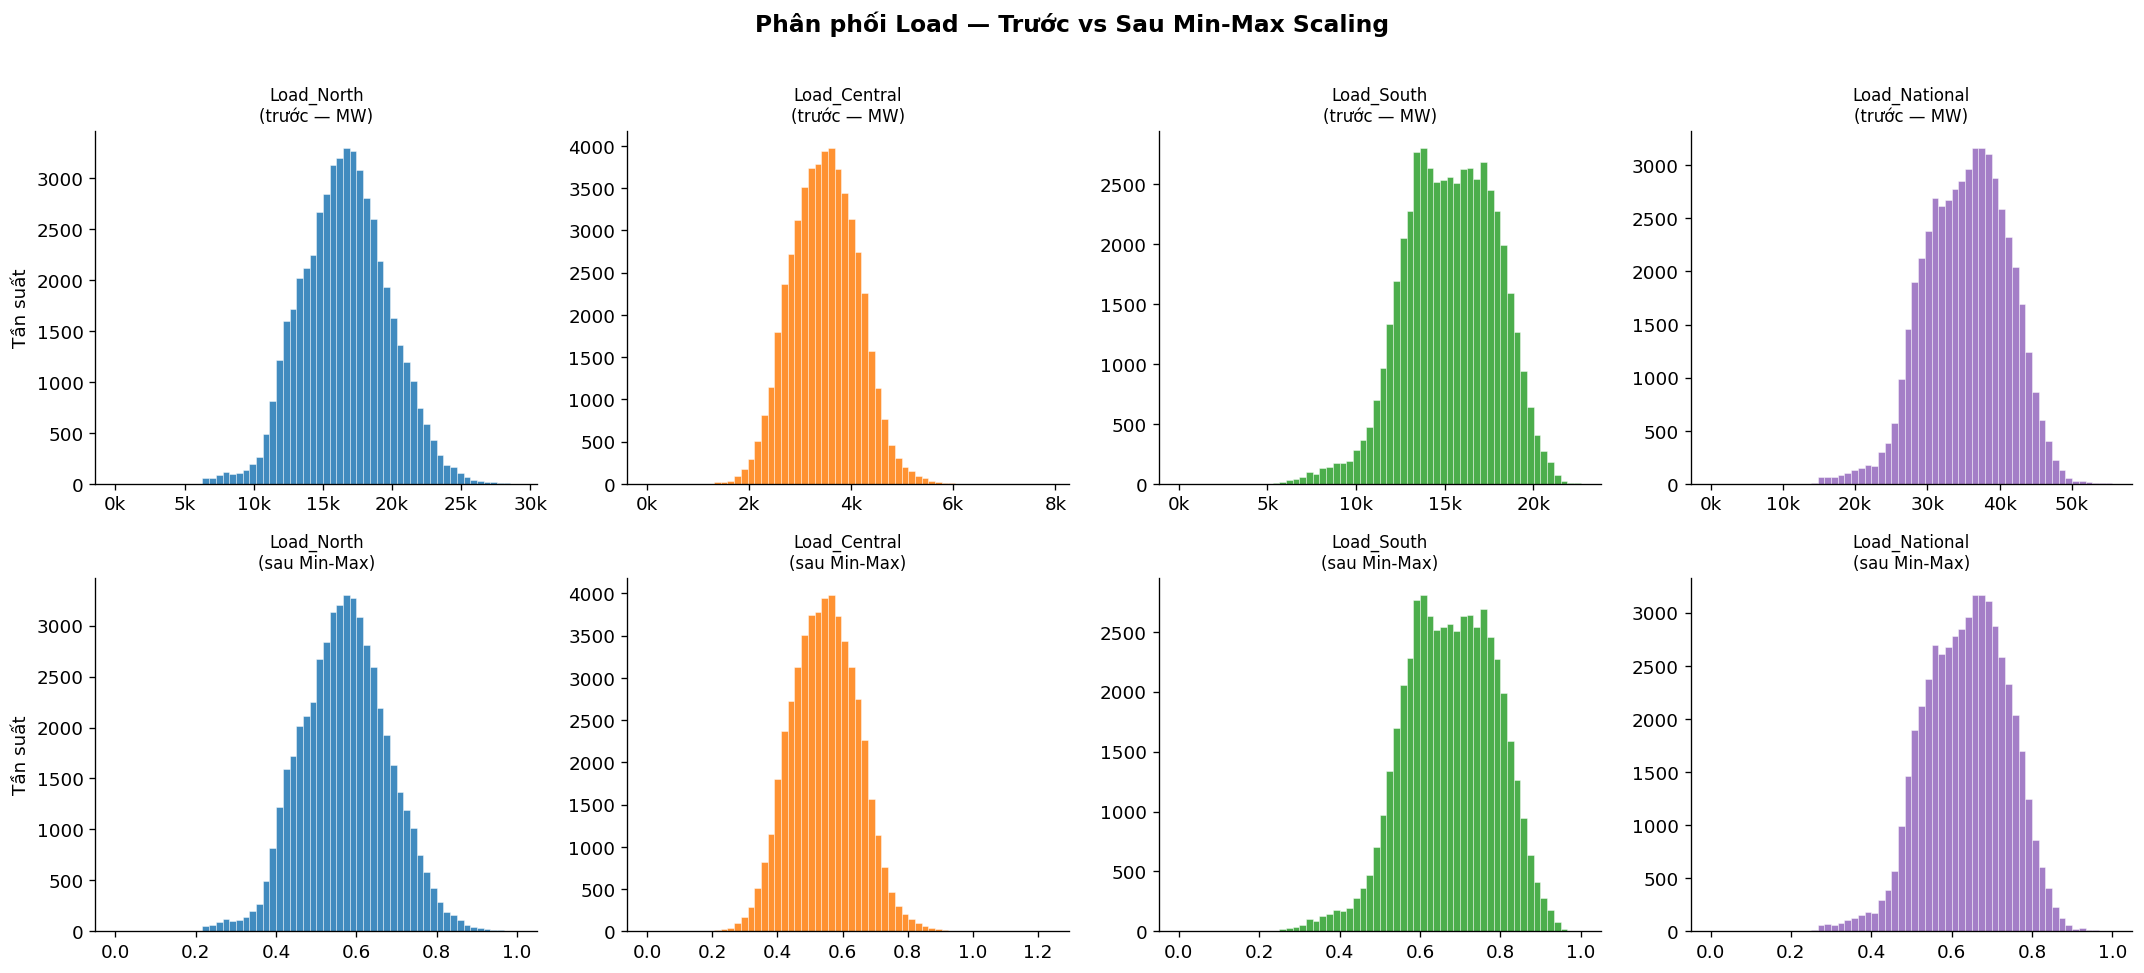

[OK] Lưu → c:\Users\ASUS\DS108-Project\reports\nb06\load_distribution_before_after.png

Nhận xét: Hình dạng phân phối KHÔNG thay đổi sau Min-Max —
chỉ trục x thu về [0,1]. Load_South và Load_National có phân
phối lệch phải nhẹ do đỉnh mùa hè cao hơn trung bình.


In [12]:
# ── Phân phối Load trước vs sau Min-Max ──────────────────────────────────────
regions = ['North', 'Central', 'South', 'National']
colors  = [PALETTE[r] for r in regions]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Phân phối Load — Trước vs Sau Min-Max Scaling',
             fontsize=14, fontweight='bold', y=1.01)

for i, (region, color) in enumerate(zip(regions, colors)):
    col = f'Load_{region}'

    ax0 = axes[0, i]
    ax0.hist(df_before_scale[col].dropna(), bins=60,
             color=color, alpha=0.85, edgecolor='white', linewidth=0.3)
    ax0.set_title(f'{col}\n(trước — MW)', fontsize=10)
    ax0.set_ylabel('Tần suất' if i == 0 else '')
    ax0.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k')
    )

    ax1 = axes[1, i]
    ax1.hist(df_scaled[col].dropna(), bins=60,
             color=color, alpha=0.85, edgecolor='white', linewidth=0.3)
    ax1.set_title(f'{col}\n(sau Min-Max)', fontsize=10)
    ax1.set_ylabel('Tần suất' if i == 0 else '')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'load_distribution_before_after.png',
            dpi=120, bbox_inches='tight')
plt.show()
print(f"[OK] Lưu → {REPORTS_DIR / 'load_distribution_before_after.png'}")
print()
print("Nhận xét: Hình dạng phân phối KHÔNG thay đổi sau Min-Max —")
print("chỉ trục x thu về [0,1]. Load_South và Load_National có phân")
print("phối lệch phải nhẹ do đỉnh mùa hè cao hơn trung bình.")

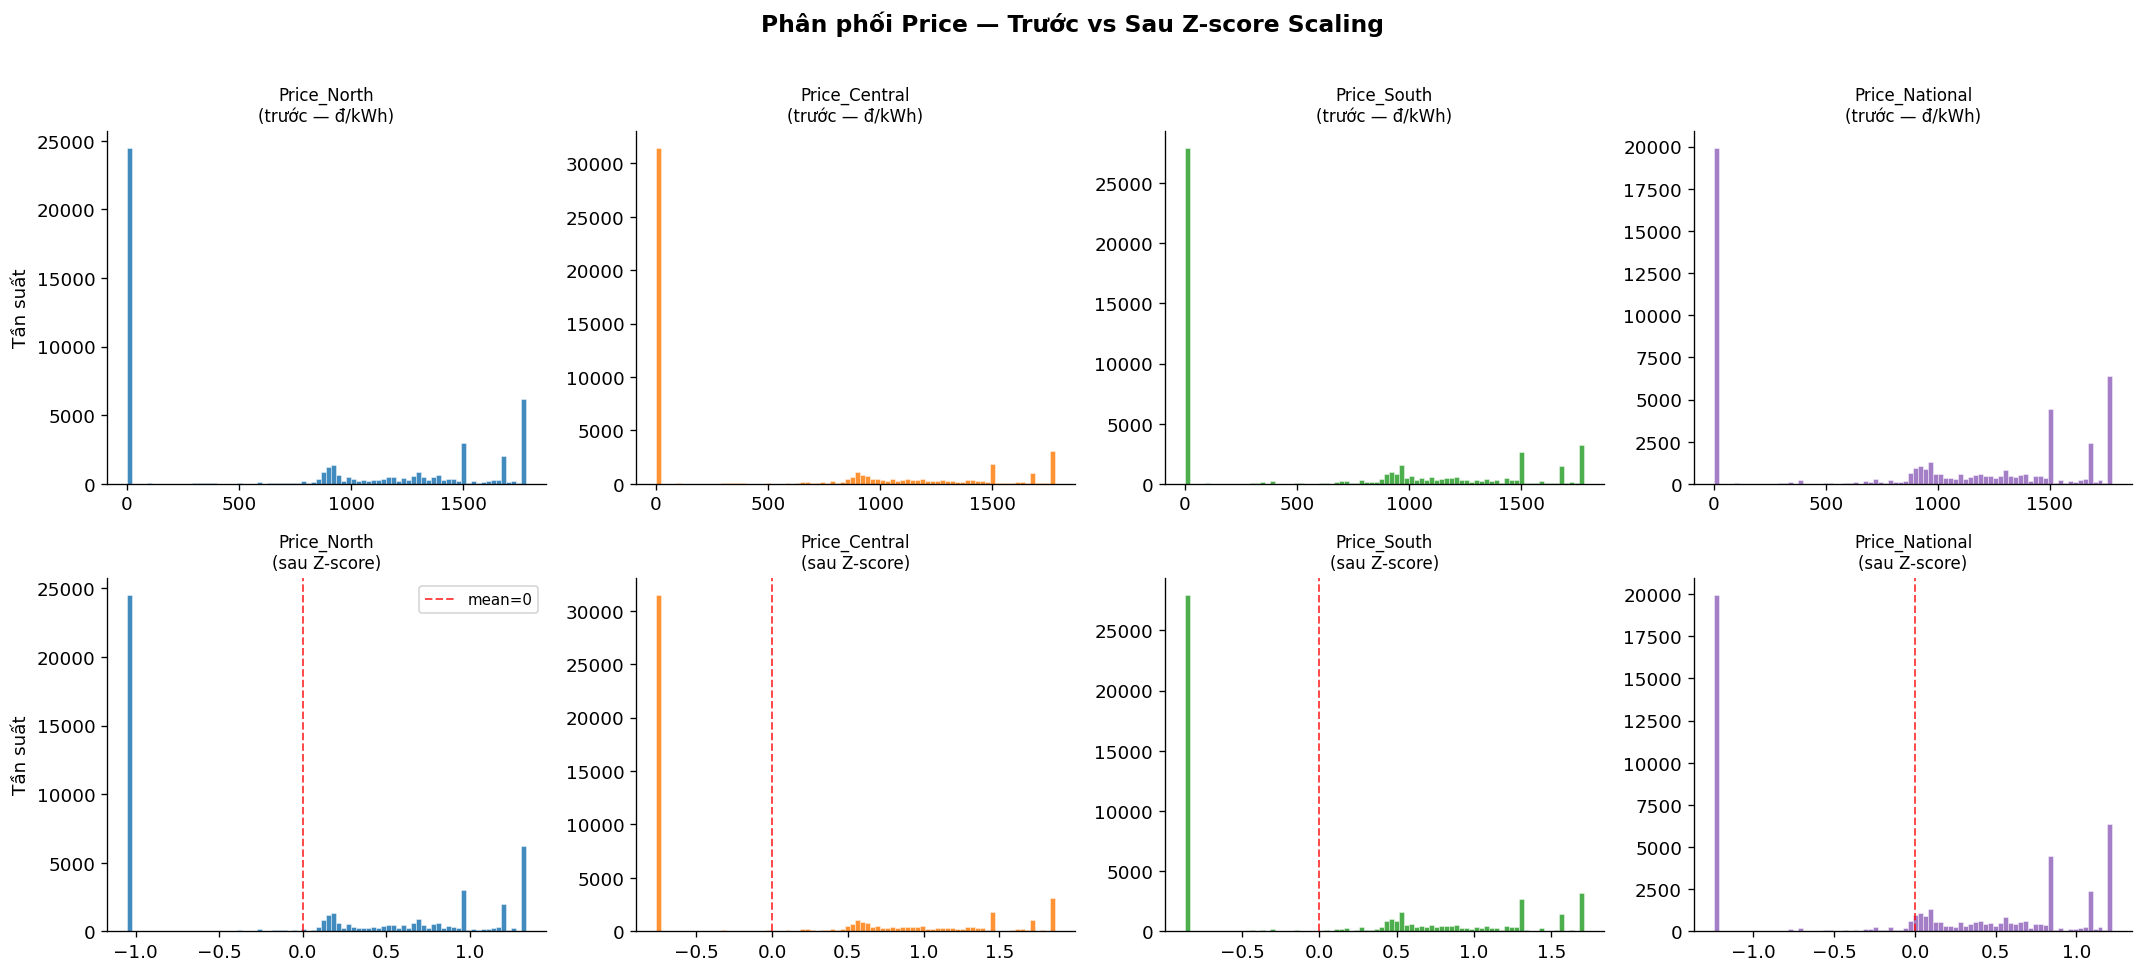

[OK] Lưu → c:\Users\ASUS\DS108-Project\reports\nb06\price_distribution_before_after.png

Nhận xét: Price có spike ở 0 (giờ dư công suất) và đuôi phải dài (3500 đ/kWh).
Z-score dịch phân phối về mean=0 nhưng không xóa spike — đây là đặc tính thực.
Min-Max sẽ bị kéo mạnh bởi spike → Z-score phù hợp hơn cho Price.


In [13]:
# ── Phân phối Price trước vs sau Z-score ─────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Phân phối Price — Trước vs Sau Z-score Scaling',
             fontsize=14, fontweight='bold', y=1.01)

for i, (region, color) in enumerate(zip(regions, colors)):
    col = f'Price_{region}'

    ax0 = axes[0, i]
    ax0.hist(df_before_scale[col].dropna(), bins=80,
             color=color, alpha=0.85, edgecolor='white', linewidth=0.3)
    ax0.set_title(f'{col}\n(trước — đ/kWh)', fontsize=10)
    ax0.set_ylabel('Tần suất' if i == 0 else '')

    ax1 = axes[1, i]
    ax1.hist(df_scaled[col].dropna(), bins=80,
             color=color, alpha=0.85, edgecolor='white', linewidth=0.3)
    ax1.axvline(0, color='red', linestyle='--', alpha=0.7, linewidth=1.2,
                label='mean=0')
    ax1.set_title(f'{col}\n(sau Z-score)', fontsize=10)
    ax1.set_ylabel('Tần suất' if i == 0 else '')
    if i == 0:
        ax1.legend(fontsize=9)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'price_distribution_before_after.png',
            dpi=120, bbox_inches='tight')
plt.show()
print(f"[OK] Lưu → {REPORTS_DIR / 'price_distribution_before_after.png'}")
print()
print("Nhận xét: Price có spike ở 0 (giờ dư công suất) và đuôi phải dài (3500 đ/kWh).")
print("Z-score dịch phân phối về mean=0 nhưng không xóa spike — đây là đặc tính thực.")
print("Min-Max sẽ bị kéo mạnh bởi spike → Z-score phù hợp hơn cho Price.")

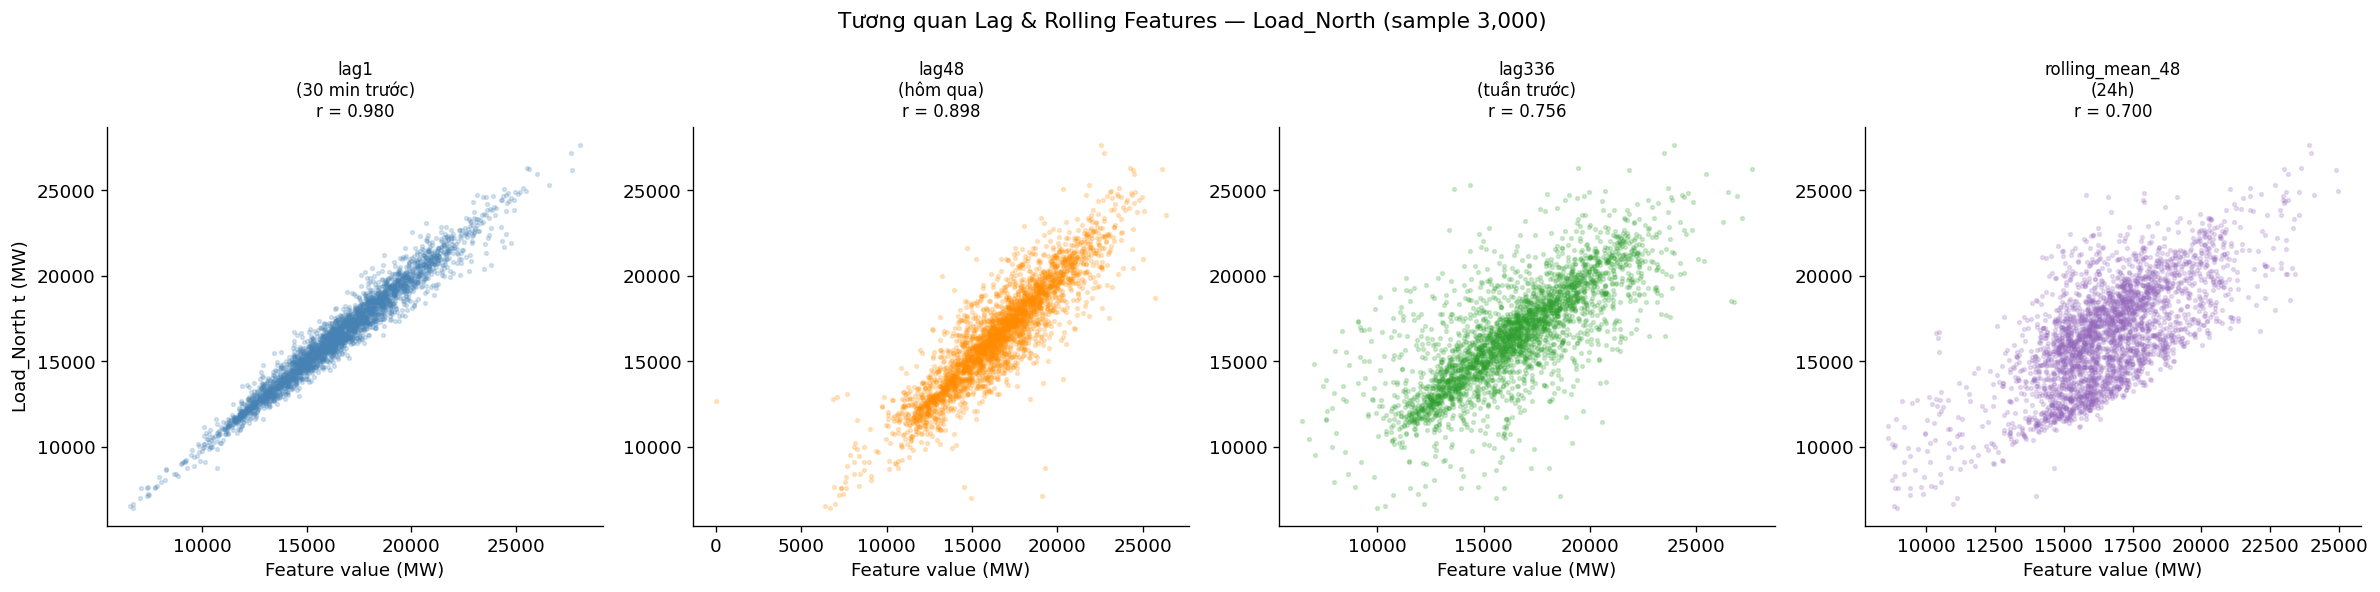

[OK] Lưu → c:\Users\ASUS\DS108-Project\reports\nb06\lag_rolling_correlation_check.png

Nhận xét:
  lag1          : tương quan rất cao — quán tính hệ thống mạnh
  lag48         : cao nhưng có phân tán hơn — daily pattern không tuyệt đối
  lag336        : tương quan cao, phân tán theo mùa — bắt weekly seasonality
  rolling_mean_48: tương quan cao, ít scatter — đại diện mức nền ổn định


In [14]:
# ── Kiểm tra tương quan lag (dùng giá trị gốc trước scale) ───────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Tương quan Lag & Rolling Features — Load_North (sample 3,000)',
             fontsize=13)

lag_pairs = [
    ('Load_North_lag1',           'lag1\n(30 min trước)',    'steelblue'),
    ('Load_North_lag48',          'lag48\n(hôm qua)',        'darkorange'),
    ('Load_North_lag336',         'lag336\n(tuần trước)',    '#2ca02c'),
    ('Load_North_rolling_mean_48','rolling_mean_48\n(24h)',  '#9467bd'),
]

check_cols = ['Load_North'] + [p[0] for p in lag_pairs]
valid = df_before_scale.dropna(subset=check_cols)
sample = valid.sample(min(3000, len(valid)), random_state=42)

for ax, (lag_col, label, color) in zip(axes, lag_pairs):
    r = sample[['Load_North', lag_col]].corr().iloc[0, 1]
    ax.scatter(sample[lag_col], sample['Load_North'],
               alpha=0.2, s=5, color=color)
    ax.set_title(f'{label}\nr = {r:.3f}', fontsize=10)
    ax.set_xlabel('Feature value (MW)')
    ax.set_ylabel('Load_North t (MW)' if ax == axes[0] else '')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'lag_rolling_correlation_check.png',
            dpi=120, bbox_inches='tight')
plt.show()
print(f"[OK] Lưu → {REPORTS_DIR / 'lag_rolling_correlation_check.png'}")
print()
print("Nhận xét:")
print("  lag1          : tương quan rất cao — quán tính hệ thống mạnh")
print("  lag48         : cao nhưng có phân tán hơn — daily pattern không tuyệt đối")
print("  lag336        : tương quan cao, phân tán theo mùa — bắt weekly seasonality")
print("  rolling_mean_48: tương quan cao, ít scatter — đại diện mức nền ổn định")

## 5. Bảng thống kê Trước vs Sau (cho báo cáo)

In [15]:
def summary_stats(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Bảng thống kê mô tả cho báo cáo."""
    rows = []
    for col in cols:
        s = df[col].dropna().describe()
        rows.append({
            'Cột':    col,
            'Min':    round(s['min'],    4),
            'Max':    round(s['max'],    4),
            'Mean':   round(s['mean'],   4),
            'Median': round(df[col].median(), 4),
            'Std':    round(s['std'],    4),
        })
    return pd.DataFrame(rows).set_index('Cột')

KEY_COLS = ['Load_North', 'Load_Central', 'Load_South', 'Load_National',
            'Price_North', 'Price_Central', 'Price_South', 'Price_National']

print("=" * 65)
print("TRƯỚC SCALING (đơn vị gốc: MW / đ/kWh)")
print("=" * 65)
print(summary_stats(df_before_scale, KEY_COLS).to_string())

print()
print("=" * 65)
print("SAU SCALING (Load: Min-Max [0,1] | Price: Z-score)")
print("=" * 65)
print(summary_stats(df_scaled, KEY_COLS).to_string())

TRƯỚC SCALING (đơn vị gốc: MW / đ/kWh)
                Min        Max        Mean      Median        Std
Cột                                                              
Load_North      0.0  29048.420  16607.3670  16590.1080  3142.4444
Load_Central    0.0   7871.793   3477.5369   3476.2070   651.8086
Load_South      0.0  22670.700  15284.4571  15341.2595  2578.8748
Load_National   0.0  55580.700  35369.2236  35637.2000  5754.8264
Price_North     0.0   1778.600    722.4813    866.9060   726.3097
Price_Central   0.0   1778.600    495.8152      0.9440   653.4716
Price_South     0.0   1778.600    580.4167      1.0000   669.6616
Price_National  0.0   1778.600    831.7089    967.1370   710.2928

SAU SCALING (Load: Min-Max [0,1] | Price: Z-score)
                   Min     Max    Mean  Median     Std
Cột                                                   
Load_North      0.0000  1.0000  0.5717  0.5711  0.1082
Load_Central    0.0000  1.2336  0.5450  0.5448  0.1021
Load_South      0.0000  1.000

In [16]:
# Boolean feature sanity check
print("Phân phối is_peak theo giờ (kiểm tra logic giờ cao điểm):")
peak_check = df_scaled.groupby('hour')['is_peak'].mean()
print(peak_check[peak_check > 0].to_string())
print()

print("is_weekend theo dayofweek (5=Thứ 7, 6=CN):")
print(df_scaled.groupby('dayofweek')['is_weekend'].mean().to_string())
print()

n_holiday_days = df_scaled[df_scaled['is_holiday'] == 1]['Timestamp'].dt.date.nunique()
print(f"Số ngày lễ trong dataset: {n_holiday_days}")

Phân phối is_peak theo giờ (kiểm tra logic giờ cao điểm):
hour
9     1.0
10    1.0
11    1.0
17    1.0
18    1.0
19    1.0
20    0.5

is_weekend theo dayofweek (5=Thứ 7, 6=CN):
dayofweek
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    1.0
6    1.0

Số ngày lễ trong dataset: 41


## 6. Validate Final Dataset

In [17]:
# ── Xử lý NaN boundary ở 2 dòng cuối dataset ─────────────────────────────────
# Nguyên nhân: weather nội suy 1h→30min ở NB05 không có điểm anchor cuối
# → 23:30 và 00:00 ngày 10/03/2026 bị NaN ở toàn bộ weather cols.
# Fix: ffill từ dòng liền trước (23:00) — hợp lý vì weather thay đổi chậm.

numeric_cols = df_scaled.select_dtypes(include='number').columns
nan_check    = df_scaled[numeric_cols].isnull().sum()
nan_cols_now = nan_check[nan_check > 0]

if not nan_cols_now.empty:
    print("[WARNING]  NaN còn sót (boundary effect từ NB05):")
    print(f"   {len(nan_cols_now)} cột × 2 dòng cuối = {nan_cols_now.sum()} NaN")
    print(f"   Timestamp: {df_scaled.loc[df_scaled[nan_cols_now.index[0]].isnull(), 'Timestamp'].tolist()}")
    print()

    weather_nan_cols = nan_cols_now.index.tolist()
    df_scaled[weather_nan_cols] = df_scaled[weather_nan_cols].ffill()

    remaining = df_scaled[weather_nan_cols].isnull().sum().sum()
    assert remaining == 0, f"Vẫn còn {remaining} NaN sau ffill!"
    print(f"[OK] Đã ffill {len(weather_nan_cols)} weather columns cho 2 dòng cuối.")
    print(f"   Logic: lấy giá trị 23:00 điền xuống 23:30 và 00:00.")
else:
    print("[OK] Không có NaN — bỏ qua bước này.")

[WARNING]  NaN còn sót (boundary effect từ NB05):
   27 cột × 2 dòng cuối = 54 NaN
   Timestamp: [Timestamp('2026-03-10 23:30:00'), Timestamp('2026-03-11 00:00:00')]

[OK] Đã ffill 27 weather columns cho 2 dòng cuối.
   Logic: lấy giá trị 23:00 điền xuống 23:30 và 00:00.


In [18]:
def validate_final_dataset(df: pd.DataFrame, scaler_params: dict) -> bool:
    """
    Kiểm tra tính hợp lệ của final dataset trước khi lưu.
    Raise AssertionError nếu có vấn đề.
    """
    print("=" * 58)
    print("  VALIDATE FINAL DATASET")
    print("=" * 58)

    numeric_cols = df.select_dtypes(include='number').columns

    # 1. Không có NaN trong numeric
    nan_total = df[numeric_cols].isnull().sum().sum()
    assert nan_total == 0, f"Còn {nan_total} NaN!"
    print(f"[OK] Không NaN trong {len(numeric_cols)} numeric columns")

    # 2. Load: min >= 0; max có thể vượt 1 vì scaler fit trên Train
    # Random Forest không nhạy với scale tuyệt đối → không assert cứng max.
    # Chỉ warn nếu vượt quá 1 để người đọc biết và có thể biện luận.
    load_cols = [c for c in df.columns
                 if c.startswith('Load_') and df[c].dtype != object]
    load_over1 = []
    for col in load_cols:
        mn, mx = df[col].min(), df[col].max()
        assert -1e-6 <= mn, f"{col} có giá trị âm: {mn:.6f}"
        if mx > 1.0 + 1e-6:
            load_over1.append((col, mx))
    if load_over1:
        print(f"[WARN] {len(load_over1)} Load columns có max > 1 (scaler fit trên Train):")
        for col, mx in load_over1:
            print(f"       {col:40s} max={mx:.6f}")
        print(f"       → Hợp lý: Test có đỉnh cao hơn Train. RF không nhạy với scale tuyệt đối.")
    else:
        print(f"[OK] {len(load_cols)} Load columns trong [0, 1]")
    print(f"[OK] Load columns không có giá trị âm ({len(load_cols)} cột)")

    # 3. Price: Train mean ≈ 0, full dataset mean có thể lệch nhẹ
    # Nới lỏng threshold vì fit trên Train, apply cho full (Train+Test)
    price_cols = [c for c in df.columns
                  if c.startswith('Price_') and df[c].dtype != object]
    for col in price_cols:
        mean_abs = abs(df[col].mean())
        assert mean_abs < 0.1, f"{col} mean={mean_abs:.4f} (kỳ vọng gần 0)"
    print(f"[OK] {len(price_cols)} Price columns có mean gần 0 (fit từ Train)")

    # 4. Không duplicate timestamp
    dup = df['Timestamp'].duplicated().sum()
    assert dup == 0, f"{dup} duplicate timestamps!"
    print("[OK] Không duplicate Timestamp")

    # 5. Mốc bắt đầu đúng (sau khi drop 336 dòng)
    expected = pd.Timestamp('2023-03-18 00:30:00')
    actual   = df['Timestamp'].min()
    assert actual == expected, f"Mốc bắt đầu: {actual} (kỳ vọng {expected})"
    print(f"[OK] Mốc bắt đầu đúng: {actual}")

    # 6. Boolean features trong {0, 1}
    for col in ['is_peak', 'is_weekend', 'is_holiday']:
        assert df[col].isin([0, 1]).all(), f"{col} chứa giá trị ngoài {{0,1}}"
    print("[OK] Boolean features trong {0, 1}")

    # 7. Scaler params đầy đủ
    expected_scale_cols = set(load_cols + price_cols)
    missing = expected_scale_cols - set(scaler_params.keys())
    assert not missing, f"Thiếu scaler params cho: {missing}"
    print(f"[OK] Scaler params đầy đủ ({len(scaler_params)} cột)")

    # 8. Có đủ 4 loại lag/rolling features
    for col in LOAD_COLS:
        for suffix in ['_lag1', '_lag48', '_lag336', '_rolling_mean_48']:
            assert f'{col}{suffix}' in df.columns, \
                f"Thiếu feature: {col}{suffix}"
    print(f"[OK] Đủ 4 loại lag/rolling × {len(LOAD_COLS)} cột Load")

    print("=" * 58)
    print(f"  [OK] ALL CHECKS PASSED")
    print(f"  Shape: {df.shape[0]:,} dòng × {df.shape[1]} cột")
    print(f"  Giai đoạn: {df['Timestamp'].min()} → {df['Timestamp'].max()}")
    print("=" * 58)
    return True


validate_final_dataset(df_scaled, scaler_params)

  VALIDATE FINAL DATASET
[OK] Không NaN trong 57 numeric columns
[WARN] 10 Load columns có max > 1 (scaler fit trên Train):
       Load_Central                             max=1.233592
       Load_North_lag48                         max=1.024232
       Load_North_lag336                        max=1.024232
       Load_North_rolling_mean_48               max=1.022607
       Load_Central_lag1                        max=1.233592
       Load_Central_lag48                       max=1.313237
       Load_Central_lag336                      max=1.313237
       Load_National_lag48                      max=1.029808
       Load_National_lag336                     max=1.029808
       Load_National_rolling_mean_48            max=1.018320
       → Hợp lý: Test có đỉnh cao hơn Train. RF không nhạy với scale tuyệt đối.
[OK] Load columns không có giá trị âm (20 cột)
[OK] 4 Price columns có mean gần 0 (fit từ Train)
[OK] Không duplicate Timestamp
[OK] Mốc bắt đầu đúng: 2023-03-18 00:30:00
[OK] Boolean fe

True

## 7. Lưu Output

In [19]:
# Sắp xếp cột theo thứ tự logic
meta_cols    = ['Timestamp']
time_cols    = ['hour', 'dayofweek', 'month']
bool_cols    = ['is_peak', 'is_weekend', 'is_holiday']
load_cols_o  = [c for c in df_scaled.columns
                if c.startswith('Load_') and '_lag' not in c and '_rolling' not in c]
price_cols_o = [c for c in df_scaled.columns if c.startswith('Price_')]
lag_cols_o   = sorted([c for c in df_scaled.columns
                       if '_lag' in c or '_rolling' in c])
weather_cols = [
    c for c in df_scaled.columns
    if c not in set(meta_cols + time_cols + bool_cols
                    + load_cols_o + price_cols_o + lag_cols_o)
]

final_order = (meta_cols + time_cols + bool_cols
               + load_cols_o + price_cols_o
               + lag_cols_o + weather_cols)

assert set(final_order) == set(df_scaled.columns), "Mất cột trong sắp xếp!"
df_final = df_scaled[final_order]

print("Cấu trúc cột cuối cùng:")
groups_out = [
    ('Meta',         meta_cols),
    ('Time',         time_cols),
    ('Boolean',      bool_cols),
    ('Load',         load_cols_o),
    ('Price',        price_cols_o),
    ('Lag+Rolling',  lag_cols_o),
    ('Weather',      weather_cols),
]
for name, cols in groups_out:
    sample_str = str(cols[:2])[:-1] + ', ...]' if len(cols) > 2 else str(cols)
    print(f"  {name:15s}: {len(cols):2d} cột  {sample_str}")

print(f"\nTổng: {len(final_order)} cột")

Cấu trúc cột cuối cùng:
  Meta           :  1 cột  ['Timestamp']
  Time           :  3 cột  ['hour', 'dayofweek', ...]
  Boolean        :  3 cột  ['is_peak', 'is_weekend', ...]
  Load           :  4 cột  ['Load_North', 'Load_Central', ...]
  Price          :  4 cột  ['Price_North', 'Price_Central', ...]
  Lag+Rolling    : 16 cột  ['Load_Central_lag1', 'Load_Central_lag336', ...]
  Weather        : 33 cột  ['temp_North', 'feelslike_North', ...]

Tổng: 64 cột


In [20]:
# Lưu CSV
df_final.to_csv(OUTPUT_DATASET, index=False, encoding='utf-8-sig')
size_mb = OUTPUT_DATASET.stat().st_size / 1024 / 1024
print(f"[OK] Lưu → {OUTPUT_DATASET}")
print(f"   Size  : {size_mb:.1f} MB")
print(f"   Shape : {df_final.shape}")
print()

# Xác nhận đọc lại
df_check = pd.read_csv(OUTPUT_DATASET, encoding='utf-8-sig', parse_dates=['Timestamp'])
assert df_check.shape == df_final.shape
print(f"[OK] Đọc lại OK — shape khớp: {df_check.shape}")

[OK] Lưu → c:\Users\ASUS\DS108-Project\data\processed\final_v1_dataset.csv
   Size  : 35.7 MB
   Shape : (52272, 64)

[OK] Đọc lại OK — shape khớp: (52272, 64)


## 8. Tổng kết Notebook 06

In [21]:
print("=" * 65)
print("  TỔNG KẾT — Notebook 06: Feature Engineering & Normalization")
print("=" * 65)
print()
print("INPUT:")
print(f"  unified_v1_merged.csv    {INPUT_SHAPE[0]:,} dòng × {INPUT_SHAPE[1]} cột")
print()
print("FEATURE ENGINEERING:")
print("  + hour, dayofweek, month               (3 time features)")
print("  + is_peak, is_weekend, is_holiday       (3 boolean features)")
print("  + Load_*_lag1                           (4 features — quán tính 30 phút)")
print("  + Load_*_lag48                          (4 features — daily seasonality)")
print("  + Load_*_lag336                         (4 features — weekly seasonality)")
print("  + Load_*_rolling_mean_48                (4 features — mức nền 24 giờ)")
print("  - Drop 336 dòng đầu → mốc mới: 2023-03-18 00:30:00")
print()
print("SCALING:")
print(f"  Min-Max : {len(LOAD_SCALE_COLS)} Load columns (gốc + lag + rolling)")
print(f"  Z-score : {len(PRICE_SCALE_COLS)} Price columns")
print(f"  Params  : scaler_params.json ({len(scaler_params)} entries)")
print()
print("OUTPUT:")
print(f"  final_v1_dataset.csv  {df_final.shape[0]:,} dòng × {df_final.shape[1]} cột")
print(f"  scaler_params.json")
print()
print("NEXT: Notebook 07 — EDA toàn diện trên final_v1_dataset.csv")
print("=" * 65)

  TỔNG KẾT — Notebook 06: Feature Engineering & Normalization

INPUT:
  unified_v1_merged.csv    52,608 dòng × 42 cột

FEATURE ENGINEERING:
  + hour, dayofweek, month               (3 time features)
  + is_peak, is_weekend, is_holiday       (3 boolean features)
  + Load_*_lag1                           (4 features — quán tính 30 phút)
  + Load_*_lag48                          (4 features — daily seasonality)
  + Load_*_lag336                         (4 features — weekly seasonality)
  + Load_*_rolling_mean_48                (4 features — mức nền 24 giờ)
  - Drop 336 dòng đầu → mốc mới: 2023-03-18 00:30:00

SCALING:
  Min-Max : 20 Load columns (gốc + lag + rolling)
  Z-score : 4 Price columns
  Params  : scaler_params.json (24 entries)

OUTPUT:
  final_v1_dataset.csv  52,272 dòng × 64 cột
  scaler_params.json

NEXT: Notebook 07 — EDA toàn diện trên final_v1_dataset.csv


**Note:** Cột Load_*_lag1 được khởi tạo và giữ lại trong dataset để phục vụ cho các nghiên cứu dự báo cực ngắn (1-step ahead, horizon = 30 phút). Tuy nhiên, với bài toán dự báo từ 1-24h của đồ án này, lag1 mang rủi ro rò rỉ dữ liệu tương lai (Inference Data Leakage). Do đó, biến này sẽ được chủ động filter out (loại bỏ) ở bước huấn luyện mô hình (NB08)."